In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

df = pd.read_csv('EasyVisa.csv')

In [32]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [33]:
df.drop('case_id', axis=1, inplace=True)

In [34]:
def standardize_wage(row):
    wage = row['prevailing_wage']
    unit = row['unit_of_wage']
    
    if unit == 'Hour':
        return wage * 2080  
    elif unit == 'Week':
        return wage * 52
    elif unit == 'Month':
        return wage * 12
    else: 
        return wage

df['yearly_wage'] = df.apply(standardize_wage, axis=1)

In [35]:
current_year = 2024
df['company_age'] = current_year - df['yr_of_estab']

In [36]:
df['is_certified'] = (df['case_status'] == 'Certified').astype(int)

In [37]:
edu_status = pd.crosstab(df['education_of_employee'], df['case_status'], normalize='index') * 100
print("--- Acceptance Rates by Education (%) ---")
print(edu_status, "\n")

--- Acceptance Rates by Education (%) ---
case_status            Certified     Denied
education_of_employee                      
Bachelor's             62.214188  37.785812
Doctorate              87.226277  12.773723
High School            34.035088  65.964912
Master's               78.627777  21.372223 



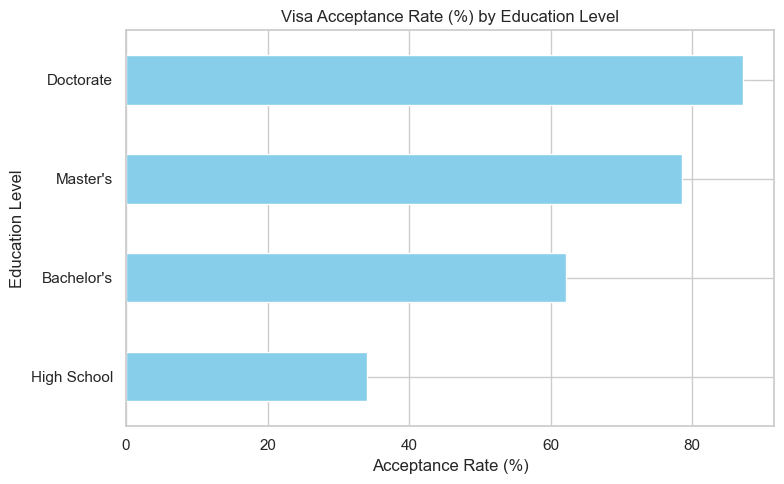

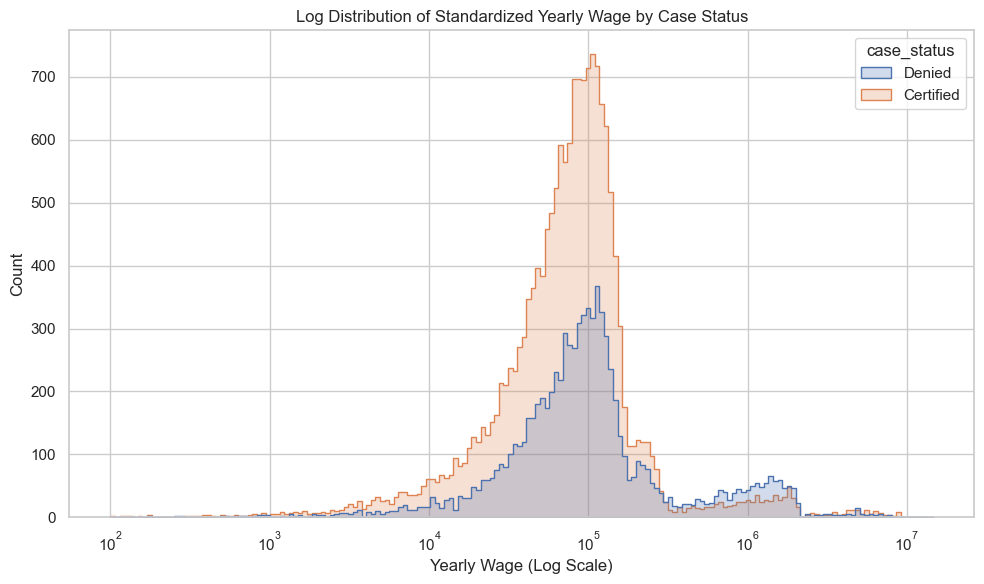

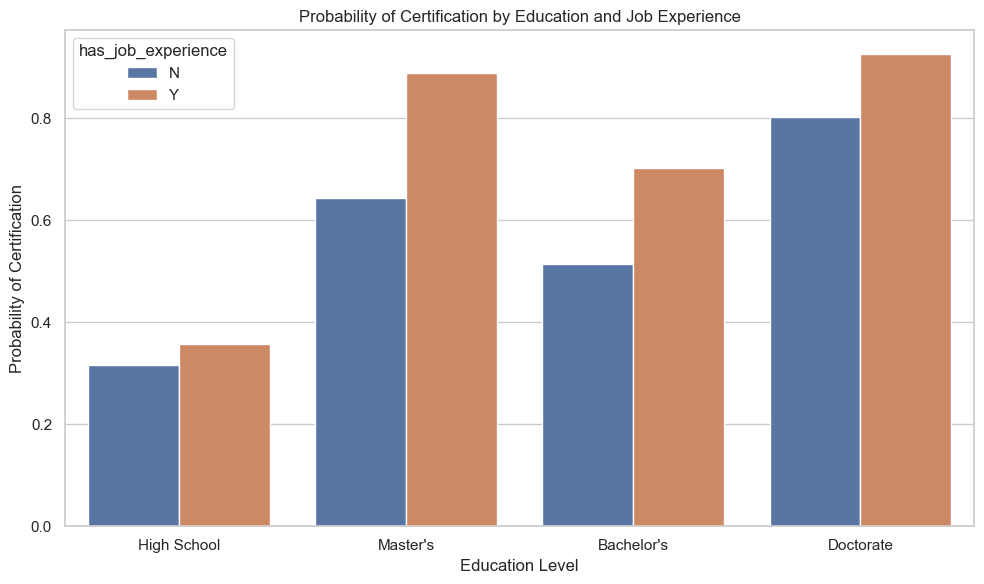

--- Chi-Square Test against Target (case_status) ---
continent:
  p-value = 8.8288e-74 | Significant Driver? Yes

education_of_employee:
  p-value = 0.0000e+00 | Significant Driver? Yes

has_job_experience:
  p-value = 1.9226e-206 | Significant Driver? Yes

requires_job_training:
  p-value = 1.8556e-01 | Significant Driver? No

region_of_employment:
  p-value = 2.3387e-63 | Significant Driver? Yes

unit_of_wage:
  p-value = 5.1934e-240 | Significant Driver? Yes

full_time_position:
  p-value = 4.4700e-02 | Significant Driver? Yes

--- Chi-Square Test for Feature Interaction ---
Education vs Experience:
  p-value = 1.8313e-01 | Are they dependent? No (They are independent)


In [38]:
sns.set_theme(style="whitegrid")

# Plot 1: Acceptance Rate by Education
plt.figure(figsize=(8, 5))
edu_status['Certified'].sort_values().plot(kind='barh', color='skyblue')
plt.title('Visa Acceptance Rate (%) by Education Level')
plt.xlabel('Acceptance Rate (%)')
plt.ylabel('Education Level')
plt.tight_layout()
plt.show()

# Plot 2: Distribution of Standardized Yearly Wage by Case Status
plt.figure(figsize=(10, 6))
# Using log_scale because wages have massive outliers
sns.histplot(data=df, x='yearly_wage', hue='case_status', log_scale=(True, False), element="step", common_norm=False)
plt.title('Log Distribution of Standardized Yearly Wage by Case Status')
plt.xlabel('Yearly Wage (Log Scale)')
plt.tight_layout()
plt.show()

# Plot 3: Multivariate Interaction (Education vs Experience vs Target)
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='education_of_employee', y='is_certified', hue='has_job_experience', errorbar=None)
plt.title('Probability of Certification by Education and Job Experience')
plt.ylabel('Probability of Certification')
plt.xlabel('Education Level')
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 5. STATISTICAL TESTING: CHI-SQUARE (Identifying Strongest Drivers)
# ---------------------------------------------------------

categorical_cols = [
    'continent', 'education_of_employee', 'has_job_experience', 
    'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position'
]

print("--- Chi-Square Test against Target (case_status) ---")
for col in categorical_cols:
    # Create a contingency table
    contingency_table = pd.crosstab(df[col], df['case_status'])
    
    # Run the Chi-Square test
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    # Print the results
    is_significant = "Yes" if p < 0.05 else "No"
    print(f"{col}:")
    print(f"  p-value = {p:.4e} | Significant Driver? {is_significant}\n")

print("--- Chi-Square Test for Feature Interaction ---")
# Testing if Education and Experience interact with each other
contingency_table_interaction = pd.crosstab(df['education_of_employee'], df['has_job_experience'])
chi2_int, p_int, dof_int, expected_int = chi2_contingency(contingency_table_interaction)

is_interacting = "Yes" if p_int < 0.05 else "No (They are independent)"
print(f"Education vs Experience:\n  p-value = {p_int:.4e} | Are they dependent? {is_interacting}")

In [39]:
df['no_of_employees'] = df['no_of_employees'].abs()

In [40]:
columns_to_drop = ['prevailing_wage', 'unit_of_wage', 'yr_of_estab', 'requires_job_training']
df.drop(columns=columns_to_drop, inplace=True)

In [41]:
df.head()

,continent,education_of_employee,has_job_experience,no_of_employees,region_of_employment,full_time_position,case_status,yearly_wage,company_age,is_certified
0,Asia,High School,N,14513,West,Y,Denied,1231782.032,17,0
1,Asia,Master's,Y,2412,Northeast,Y,Certified,83425.650,22,1
2,Asia,Bachelor's,N,44444,West,Y,Denied,122996.860,16,0
3,Asia,Bachelor's,N,98,West,Y,Denied,83434.030,127,0
4,Africa,Master's,Y,1082,South,Y,Certified,149907.390,19,1


In [42]:
binary_cols = ['has_job_experience', 'full_time_position']
for col in binary_cols:
    df[col] = df[col].map({'Y': 1, 'N': 0})

In [43]:
education_map = {
    'High School': 0,
    "Bachelor's": 1,
    "Master's": 2,
    'Doctorate': 3
}
df['education_of_employee'] = df['education_of_employee'].map(education_map)

In [44]:
df = pd.get_dummies(df, columns=['continent', 'region_of_employment'], drop_first=True)

In [45]:
df.head()

,education_of_employee,has_job_experience,no_of_employees,full_time_position,case_status,yearly_wage,company_age,is_certified,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West
0,0,0,14513,1,Denied,1231782.032,17,0,True,False,False,False,False,False,False,False,True
1,2,1,2412,1,Certified,83425.650,22,1,True,False,False,False,False,False,True,False,False
2,1,0,44444,1,Denied,122996.860,16,0,True,False,False,False,False,False,False,False,True
3,1,0,98,1,Denied,83434.030,127,0,True,False,False,False,False,False,False,False,True
4,2,1,1082,1,Certified,149907.390,19,1,False,False,False,False,False,False,False,True,False


In [46]:
df.drop(columns=['case_status'], inplace=True)

In [47]:
df.head()

,education_of_employee,has_job_experience,no_of_employees,full_time_position,yearly_wage,company_age,is_certified,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West
0,0,0,14513,1,1231782.032,17,0,True,False,False,False,False,False,False,False,True
1,2,1,2412,1,83425.650,22,1,True,False,False,False,False,False,True,False,False
2,1,0,44444,1,122996.860,16,0,True,False,False,False,False,False,False,False,True
3,1,0,98,1,83434.030,127,0,True,False,False,False,False,False,False,False,True
4,2,1,1082,1,149907.390,19,1,False,False,False,False,False,False,False,True,False


In [48]:
from sklearn.model_selection import train_test_split
X = df.drop('is_certified', axis=1)
y = df['is_certified']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [49]:
cols_to_scale = ['no_of_employees', 'yearly_wage', 'company_age']

In [50]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [51]:
print(f"X_train Shape (After Preprocessing): {X_train.shape}")
print(f"X_test Shape (After Preprocessing): {X_test.shape}")

X_train Shape (After Preprocessing): (20384, 15)
X_test Shape (After Preprocessing): (5096, 15)
